# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


## Perkenalan Dataset

Pada proyek akhir ini digunakan dataset ulasan pengguna aplikasi DANA yang diperoleh dari Google Play Store menggunakan library `google-play-scraper`. Dataset terdiri dari 5000 ulasan pengguna yang diambil berdasarkan review paling relevan (`Sort.MOST_RELEVANT`).

Setiap ulasan memiliki rating 1 hingga 5 yang kemudian dikonversi menjadi label sentimen, yaitu negatif (rating 1–2), netral (rating 3), dan positif (rating 4–5).

Tujuan dari proyek akhir ini adalah membangun model klasifikasi sentimen untuk mengidentifikasi opini pengguna terhadap aplikasi DANA berdasarkan ulasan yang diberikan.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
!pip install google-play-scraper
from google_play_scraper import reviews, Sort
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

import unicodedata

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.1 MB/s eta 0:00:00


In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
result, _ = reviews(
    "id.dana",
    lang="id",
    country="id",
    count=5000,
    sort=Sort.MOST_RELEVANT
)

df = pd.DataFrame(result)

df = df[['content','score']]

print("Shape dataset : ", df.shape)

df.head()

Shape dataset :  (5000, 2)


,content,score
0,Saya tidak menyangka proses pengajuan pinjaman...,5
1,"Fermuk wajah sama KTP sudah jelas sama, cahaya...",1
2,aplikasi sangat mengecewakan tiba tiba akun di...,5
3,"bagus sih,tapi kenapa sekarang setiap saya ing...",4
4,Aplikasi DANA menurut saya sangat membantu dal...,5


In [4]:
df.to_csv(
    'dana_reviews_raw.csv',
    index=False
)

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  5000 non-null   object
 1   score    5000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 78.3+ KB


In [6]:
df.isnull().sum()

,0
content,0
score,0


In [7]:
df.describe(include='all')

,content,score
count,5000,5000.000000
unique,5000,NaN
top,"kurang satu fitur,gak ada fitur dana cicilnya",NaN
freq,1,NaN
mean,NaN,2.456800
std,NaN,1.680565
min,NaN,1.000000
25%,NaN,1.000000
50%,NaN,2.000000
75%,NaN,4.000000


In [8]:
print("Total Data : ", len(df))
print("Review Unik : ", len(df['content'].unique()))

Total Data :  5000
Review Unik :  5000


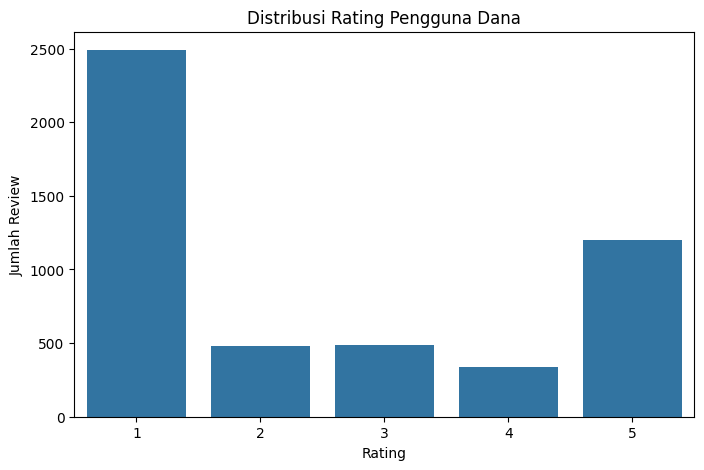

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="score"
)

plt.title("Distribusi Rating Pengguna Dana")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")

plt.show()

In [10]:
def sentiment_lable(score) :
  if score <= 2 :
    return 'negatif'
  elif score == 3 :
    return 'netral'
  else :
    return 'positif'

df['sentiment'] = df['score'].apply(sentiment_lable)

In [11]:
df[['content','score','sentiment']].head()

,content,score,sentiment
0,Saya tidak menyangka proses pengajuan pinjaman...,5,positif
1,"Fermuk wajah sama KTP sudah jelas sama, cahaya...",1,negatif
2,aplikasi sangat mengecewakan tiba tiba akun di...,5,positif
3,"bagus sih,tapi kenapa sekarang setiap saya ing...",4,positif
4,Aplikasi DANA menurut saya sangat membantu dal...,5,positif


In [12]:
df['sentiment'].value_counts()

,count
sentiment,
negatif,2972
positif,1543
netral,485


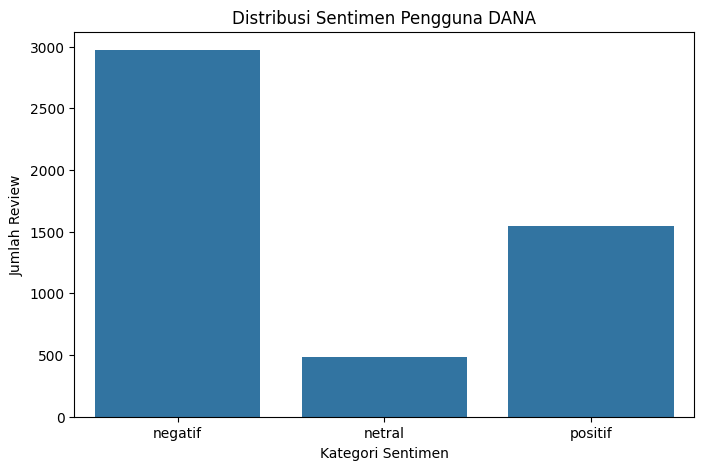

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='sentiment',
    order=['negatif','netral','positif']
)

plt.title('Distribusi Sentimen Pengguna DANA')
plt.xlabel('Kategori Sentimen')
plt.ylabel('Jumlah Review')

plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [14]:
df = df.dropna(subset=['content', 'score'])
df[['content','score']].isnull().sum()

,0
content,0
score,0


In [15]:
df = df.drop_duplicates(subset=['content'])

print("Jumlah data setelah menghapus duplikat:", len(df))

Jumlah data setelah menghapus duplikat: 5000


In [16]:
def clean_text(text) :
  text = str(text)

  text = unicodedata.normalize("NFKD", text)
  text = re.sub(r'http\S+|www\S+', '', text)
  text = re.sub(r'@\w+', '', text)
  text = re.sub(r'#\w+', '', text)
  text = re.sub(r'\d+', '', text)
  text = re.sub(r'[^a-zA-Z\s]', ' ', text)
  text = re.sub(r'\s+', ' ', text)

  return text.strip()

In [17]:
df['content_clean'] = df['content'].str.lower()
df['content_clean'] = df['content_clean'].apply(clean_text)

In [18]:
df[['content','content_clean']].head()

,content,content_clean
0,Saya tidak menyangka proses pengajuan pinjaman...,saya tidak menyangka proses pengajuan pinjaman...
1,"Fermuk wajah sama KTP sudah jelas sama, cahaya...",fermuk wajah sama ktp sudah jelas sama cahaya ...
2,aplikasi sangat mengecewakan tiba tiba akun di...,aplikasi sangat mengecewakan tiba tiba akun di...
3,"bagus sih,tapi kenapa sekarang setiap saya ing...",bagus sih tapi kenapa sekarang setiap saya ing...
4,Aplikasi DANA menurut saya sangat membantu dal...,aplikasi dana menurut saya sangat membantu dal...


In [19]:
df['tokens'] = df['content_clean'].apply(word_tokenize)

In [20]:
stop_words = set(stopwords.words('indonesian'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['tokens'] = df['tokens'].apply(remove_stopwords)

In [21]:
df[['content_clean', 'tokens']].head()

,content_clean,tokens
0,saya tidak menyangka proses pengajuan pinjaman...,"[menyangka, proses, pengajuan, pinjamannya, se..."
1,fermuk wajah sama ktp sudah jelas sama cahaya ...,"[fermuk, wajah, ktp, cahaya, terang, buset, si..."
2,aplikasi sangat mengecewakan tiba tiba akun di...,"[aplikasi, mengecewakan, akun, proteksi, trans..."
3,bagus sih tapi kenapa sekarang setiap saya ing...,"[bagus, sih, mengisi, coin, tiktok, pembayaran..."
4,aplikasi dana menurut saya sangat membantu dal...,"[aplikasi, dana, membantu, kehidupan, sehari, ..."


In [22]:
factory = StemmerFactory()
stemer = factory.create_stemmer()

def steming(tokens):
  sentence = " ".join(tokens)
  return stemer.stem(sentence)

In [23]:
df['text_final'] = df['tokens'].apply(steming)

In [24]:
df[['content', 'text_final']].head()

,content,text_final
0,Saya tidak menyangka proses pengajuan pinjaman...,sangka proses aju pinjam mudah butuh dana desa...
1,"Fermuk wajah sama KTP sudah jelas sama, cahaya...",fermuk wajah ktp cahaya terang buset sinyal ku...
2,aplikasi sangat mengecewakan tiba tiba akun di...,aplikasi kecewa akun proteksi transaksi saat g...
3,"bagus sih,tapi kenapa sekarang setiap saya ing...",bagus sih isi coin tiktok bayar dana ya kena l...
4,Aplikasi DANA menurut saya sangat membantu dal...,aplikasi dana bantu hidup hari tampil bagus mu...


In [25]:
df[['content', 'content_clean', 'text_final']].sample(5)

,content,content_clean,text_final
4128,"sebebernya bagus, tapii mohon ini aku udah ber...",sebebernya bagus tapii mohon ini aku udah beru...,beber bagus tapi mohon udah ulang kali nyoba t...
2386,"dana ini kenapa sekarang, kuq transfer menungg...",dana ini kenapa sekarang kuq transfer menunggu...,dana kuq transfer tunggu nunggu brp menit eh x...
2460,"ga bisa login padahal habis top up, jadi gabis...",ga bisa login padahal habis top up jadi gabisa...,ga login habis top up gabisa bayar paylater yg...
4868,"Terimakasih,Tolong fitur yg sudah di sediakan ...",terimakasih tolong fitur yg sudah di sediakan ...,terimakasih tolong fitur yg sedia jgn sulit tks
995,"aplikasi buruk, aplikasi suka maling dana, beb...",aplikasi buruk aplikasi suka maling dana beber...,aplikasi buruk aplikasi suka maling dana kali ...


In [26]:
df_final = df[['text_final', 'sentiment']]

df_final.to_csv(
    'dataset_preprocessing.csv',
    index=False
)

In [27]:
df_final.head()

,text_final,sentiment
0,sangka proses aju pinjam mudah butuh dana desa...,positif
1,fermuk wajah ktp cahaya terang buset sinyal ku...,negatif
2,aplikasi kecewa akun proteksi transaksi saat g...,positif
3,bagus sih isi coin tiktok bayar dana ya kena l...,positif
4,aplikasi dana bantu hidup hari tampil bagus mu...,positif
